# 🏏 IPL Ball-by-Ball Analytics — Hackathon Submission
### Advanced Cricket Data Science | Deep Dive

---

**Objective:** Analyze ~290K IPL deliveries to uncover actionable insights about toss impact, phase dominance, and elite player performance.

**Research Questions:**
1. Do teams that win the toss actually win more matches?
2. Which match phase is most linked to winning?
3. Who are the top 5 batters and bowlers?
4. What is one surprising data-driven insight?

**Tech Stack:** `pandas` · `numpy` · `matplotlib` · `seaborn`

---

## 📦 Section 1 — Imports & Global Styling

In [1]:
# ── Core Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global Plot Configuration ──
sns.set_theme(style='whitegrid', font_scale=1.15, palette='deep')

PLOT_STYLE = {
    'figure.figsize': (12, 6),
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
}
plt.rcParams.update(PLOT_STYLE)

# ── IPL-Inspired Color Palette ──
C_PRIMARY   = '#1a237e'   # Deep indigo
C_SECONDARY = '#e65100'   # Vibrant orange
C_SUCCESS   = '#2e7d32'   # Green
C_DANGER    = '#c62828'   # Red
C_ACCENT    = '#6a1b9a'   # Purple
C_GOLD      = '#FFD700'
C_SILVER    = '#A8A9AD'
C_BRONZE    = '#CD7F32'

CHART_DIR = '../charts/'
import os
os.makedirs(CHART_DIR, exist_ok=True)

print("Libraries loaded. Plot style configured. Chart directory ready.")

Libraries loaded. Plot style configured. Chart directory ready.


## 📂 Section 2 — Load Dataset

In [2]:
# ── Load CSV safely ──
DATA_PATH = '../data/ipl_matches.csv'
try:
    df_raw = pd.read_csv(DATA_PATH, low_memory=False)
    print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
except FileNotFoundError:
    raise SystemExit(f"File not found: {DATA_PATH}")

df_raw.head()

Loaded: 289,673 rows x 30 columns


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


## 🔍 Section 3 — Dataset Overview

In [3]:
# ── Shape & Columns ──
print(f"Shape: {df_raw.shape}")
print(f"\nColumns ({len(df_raw.columns)}):")
for i, c in enumerate(df_raw.columns, 1):
    print(f"   {i:2d}. {c}")

Shape: (289673, 30)

Columns (30):
    1. match_id
    2. date
    3. season
    4. event
    5. venue
    6. city
    7. team1
    8. team2
    9. toss_winner
   10. toss_decision
   11. winner
   12. win_by_runs
   13. win_by_wickets
   14. player_of_match
   15. innings
   16. batting_team
   17. over
   18. ball
   19. batter
   20. bowler
   21. non_striker
   22. runs_batter
   23. runs_extras
   24. runs_total
   25. extras_wides
   26. extras_noballs
   27. extras_byes
   28. extras_legbyes
   29. wicket_kind
   30. wicket_player_out


In [4]:
# ── Missing Values ──
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Count': miss, '%': miss_pct}).query('Count > 0').sort_values('%', ascending=False)
print("Missing Values:")
display(miss_df)

Missing Values:


,Count,%
wicket_kind,275267,95.03
wicket_player_out,275267,95.03
win_by_runs,156126,53.90
win_by_wickets,138527,47.82
city,12397,4.28
player_of_match,828,0.29


In [5]:
# ── Data Types ──
print("Data Types:")
print(df_raw.dtypes.to_string())

Data Types:
match_id               int64
date                     str
season                   str
event                    str
venue                    str
city                     str
team1                    str
team2                    str
toss_winner              str
toss_decision            str
winner                   str
win_by_runs          float64
win_by_wickets       float64
player_of_match          str
innings                int64
batting_team             str
over                   int64
ball                   int64
batter                   str
bowler                   str
non_striker              str
runs_batter            int64
runs_extras            int64
runs_total             int64
extras_wides           int64
extras_noballs         int64
extras_byes            int64
extras_legbyes         int64
wicket_kind              str
wicket_player_out        str


## 🧹 Section 4 — Data Cleaning

In [6]:
# ── Create working copy (never mutate raw) ──
df = df_raw.copy()

# ── Fix mixed-type season column ──
df['season'] = df['season'].astype(str).str.strip()

# ── Strip whitespace from all string columns ──
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

# ── Ensure numeric types ──
df['over'] = pd.to_numeric(df['over'], errors='coerce')
df['runs_batter'] = pd.to_numeric(df['runs_batter'], errors='coerce').fillna(0).astype(int)
df['runs_total'] = pd.to_numeric(df['runs_total'], errors='coerce').fillna(0).astype(int)

# ── Fill missing city ──
df['city'] = df['city'].fillna('Unknown')

# ── Remove exact duplicates ──
dup = df.duplicated().sum()
if dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {dup:,} duplicates.")
else:
    print("No duplicates found.")

print(f"Cleaned: {df.shape[0]:,} rows x {df.shape[1]} columns")

No duplicates found.
Cleaned: 289,673 rows x 30 columns


## ⚙️ Section 5 — Feature Engineering

In [7]:
# ── Helper: classify match phase (overs are 0-indexed) ──
def get_phase(over_val):
    """Powerplay=0-5, Middle=6-14, Death=15-19"""
    try:
        o = int(over_val)
    except (ValueError, TypeError):
        return 'Unknown'
    if   o <= 5:  return 'Powerplay (1-6)'
    elif o <= 14: return 'Middle Overs (7-15)'
    elif o <= 19: return 'Death Overs (16-20)'
    return 'Unknown'

df['phase'] = df['over'].apply(get_phase)

# ── Validate phase distribution ──
print("Phase column created:")
print(df['phase'].value_counts().to_string())

Phase column created:
phase
Middle Overs (7-15)    132841
Powerplay (1-6)         91014
Death Overs (16-20)     65818


In [8]:
# ── Phase Mapping Validation ──
# Verify that zero-indexed overs map to correct IPL phases

phase_check = (
    df[['over', 'phase']]
    .drop_duplicates()
    .sort_values('over')
    .reset_index(drop=True)
)

print("Over → Phase Mapping (all unique combinations):")
print("-" * 40)
display(phase_check)

# ── Automated validation ──
expected = {
    range(0, 6):   'Powerplay (1-6)',
    range(6, 15):  'Middle Overs (7-15)',
    range(15, 20): 'Death Overs (16-20)',
}

errors = []
for over_range, expected_phase in expected.items():
    for o in over_range:
        actual = phase_check.loc[phase_check['over'] == o, 'phase']
        if actual.empty or actual.values[0] != expected_phase:
            errors.append(f"  Over {o}: expected '{expected_phase}', got '{actual.values[0] if not actual.empty else 'MISSING'}'")

if not errors:
    print("\n✅ Phase mapping validated — all 20 overs map correctly.")
else:
    print("\n❌ Phase mapping errors found:")
    for e in errors:
        print(e)

Over → Phase Mapping (all unique combinations):
----------------------------------------


,over,phase
0,0,Powerplay (1-6)
1,1,Powerplay (1-6)
2,2,Powerplay (1-6)
3,3,Powerplay (1-6)
4,4,Powerplay (1-6)
5,5,Powerplay (1-6)
6,6,Middle Overs (7-15)
7,7,Middle Overs (7-15)
8,8,Middle Overs (7-15)
9,9,Middle Overs (7-15)



✅ Phase mapping validated — all 20 overs map correctly.


In [9]:
# ── Build match-level dataframe (1 row per match) ──
match_cols = ['match_id','season','team1','team2','toss_winner',
              'toss_decision','winner','venue','city']
existing = [c for c in match_cols if c in df.columns]
matches = df.groupby('match_id')[existing].first().reset_index(drop=True)

# ── Toss-related features ──
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']
matches['toss_loser_won'] = matches['toss_winner'] != matches['winner']

print(f"Match-level dataframe: {matches.shape[0]:,} matches")
matches.head()

Match-level dataframe: 1,218 matches


,match_id,season,team1,team2,toss_winner,toss_decision,winner,venue,city,toss_won_match,toss_loser_won
0,335982,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,M Chinnaswamy Stadium,Bangalore,False,True
1,335983,2007/08,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,True,False
2,335984,2007/08,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,Feroz Shah Kotla,Delhi,False,True
3,335985,2007/08,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,Wankhede Stadium,Mumbai,False,True
4,335986,2007/08,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,Eden Gardens,Kolkata,False,True


## 🎯 Section 6 — Toss Impact Analysis
> **Q1: Does winning the toss provide a statistically meaningful advantage?**

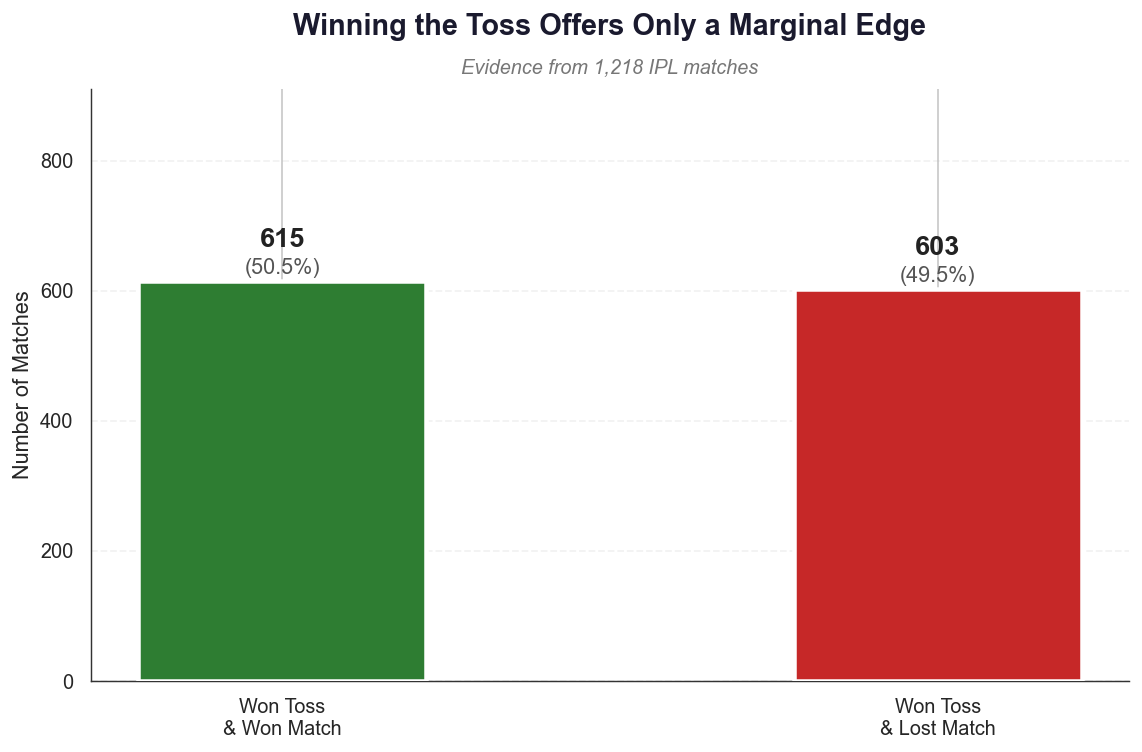

With a near-even split (50.5% vs 49.5%), toss advantage appears
statistically marginal — just 0.5 pp above a coin flip — relative to on-field execution.


In [10]:
# ── Toss Winner Win Rate ──
toss_counts = matches['toss_won_match'].value_counts()
toss_pcts   = matches['toss_won_match'].value_counts(normalize=True) * 100

won  = toss_counts.get(True, 0)
lost = toss_counts.get(False, 0)
won_pct  = toss_pcts.get(True, 0)
lost_pct = toss_pcts.get(False, 0)

# ── Chart ──
fig, ax = plt.subplots(figsize=(9, 6))

labels = ['Won Toss\n& Won Match', 'Won Toss\n& Lost Match']
vals   = [won, lost]
colors = [C_SUCCESS, C_DANGER]

bars = ax.bar(labels, vals, color=colors, width=0.44,
              edgecolor='white', linewidth=2.5, zorder=3)

# ── Annotations ──
for bar, v, p in zip(bars, vals, [won_pct, lost_pct]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 45,
            f'{v:,}', ha='center', va='bottom',
            fontweight='bold', fontsize=15, color='#222')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'({p:.1f}%)', ha='center', va='bottom',
            fontsize=12, color='#555')

# ── Title + subtitle ──
ax.set_title('Winning the Toss Offers Only a Marginal Edge',
             pad=30, fontsize=16, fontweight='bold', color='#1a1a2e')
ax.text(0.5, 1.025, f'Evidence from {len(matches):,} IPL matches',
        transform=ax.transAxes, ha='center', fontsize=11,
        color='#777', style='italic')

ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_ylim(0, max(vals) * 1.48)
ax.grid(axis='y', alpha=0.18, linestyle='--', color='#bbb')
sns.despine()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}01_toss_impact.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Insight ──
diff = abs(won_pct - 50)
print(f"With a near-even split ({won_pct:.1f}% vs {lost_pct:.1f}%), toss advantage appears")
print(f"statistically marginal — just {diff:.1f} pp above a coin flip — relative to on-field execution.")

## 📊 Section 7 — Match Phase Analysis
> **Q2: Which phase is most linked to winning?**

Average Runs per Ball by Phase:


,Losing Team,Winning Team
phase,,
Powerplay (1-6),1.2140,1.3696
Middle Overs (7-15),1.2029,1.3616
Death Overs (16-20),1.4555,1.7509


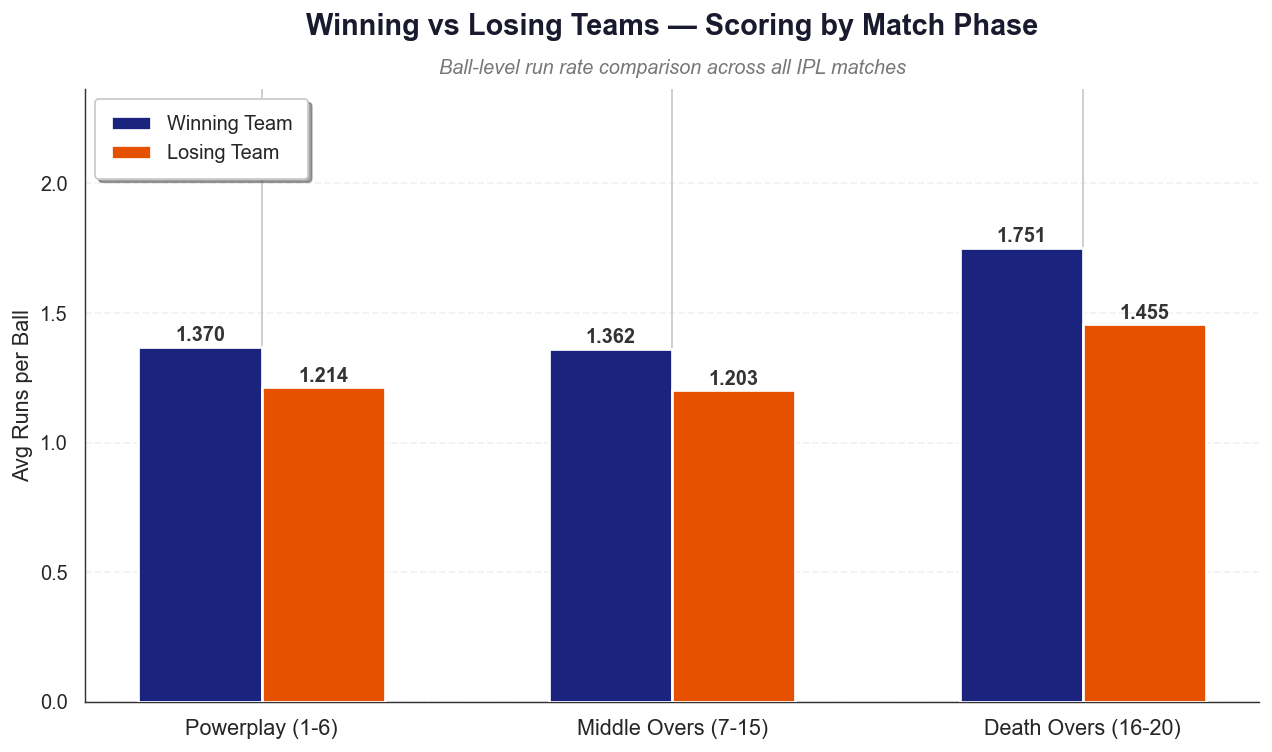

Winning teams exhibit the largest scoring separation during the Death Overs (16-20)
(+0.2954 RPB), highlighting the importance of late-innings acceleration.


In [11]:
# ── Tag each delivery: is batting team the match winner? ──
df['is_winner_batting'] = (df['batting_team'] == df['winner'])

PHASES = ['Powerplay (1-6)', 'Middle Overs (7-15)', 'Death Overs (16-20)']

# ── Average runs per ball by phase (winners vs losers) ──
phase_avg = (
    df[df['phase'].isin(PHASES)]
    .groupby(['phase', 'is_winner_batting'])['runs_total']
    .mean()
    .unstack()
    .reindex(PHASES)
)
phase_avg.columns = ['Losing Team', 'Winning Team']

print("Average Runs per Ball by Phase:")
display(phase_avg.round(4))

# ── Chart ──
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(PHASES))
w = 0.30

b1 = ax.bar(x - w/2, phase_avg['Winning Team'], w, label='Winning Team',
            color=C_PRIMARY, edgecolor='white', linewidth=1.5, zorder=3)
b2 = ax.bar(x + w/2, phase_avg['Losing Team'], w, label='Losing Team',
            color=C_SECONDARY, edgecolor='white', linewidth=1.5, zorder=3)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.006,
                f'{h:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(PHASES, fontsize=12)
ax.set_ylabel('Avg Runs per Ball', fontsize=12)

# ── Title + subtitle ──
ax.set_title('Winning vs Losing Teams — Scoring by Match Phase',
             pad=30, fontsize=16, fontweight='bold', color='#1a1a2e')
ax.text(0.5, 1.025, 'Ball-level run rate comparison across all IPL matches',
        transform=ax.transAxes, ha='center', fontsize=11,
        color='#777', style='italic')

ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True,
          loc='upper left', borderpad=0.8)
ax.set_ylim(0, phase_avg.values.max() * 1.35)
ax.grid(axis='y', alpha=0.18, linestyle='--', color='#bbb')
sns.despine()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}02_phase_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Insight ──
best = phase_avg['Winning Team'].idxmax()
gap  = phase_avg.loc[best, 'Winning Team'] - phase_avg.loc[best, 'Losing Team']
print(f"Winning teams exhibit the largest scoring separation during the {best}")
print(f"(+{gap:.4f} RPB), highlighting the importance of late-innings acceleration.")

## 🌟 Section 8 — Top 5 Batters
> **Q3: Which batters have accumulated the most runs across IPL seasons?**

Top 5 Run Scorers:


,Batter,Total Runs
Rank,,
1,V Kohli,9050
2,RG Sharma,7269
3,S Dhawan,6769
4,DA Warner,6567
5,KL Rahul,5680


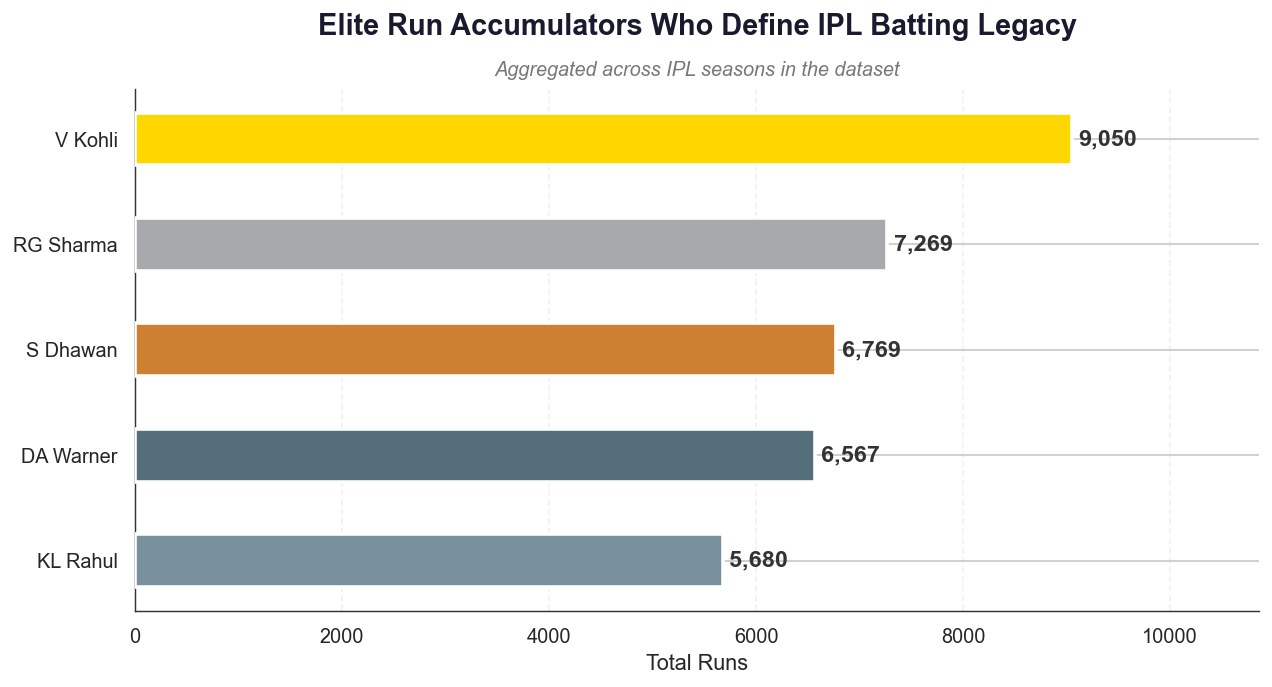

V Kohli's 1,781-run lead over RG Sharma reflects a sustained level
of batting consistency rarely matched across IPL seasons.


In [12]:
# ── Top 5 by total runs_batter ──
top_bat = (
    df.groupby('batter')['runs_batter']
    .sum()
    .nlargest(5)
    .reset_index()
)
top_bat.columns = ['Batter', 'Total Runs']
top_bat.index = range(1, 6)
top_bat.index.name = 'Rank'
print("Top 5 Run Scorers:")
display(top_bat)

# ── Chart ──
fig, ax = plt.subplots(figsize=(10, 5.5))

bar_colors = [C_GOLD, C_SILVER, C_BRONZE, '#546E7A', '#78909C']

bars = ax.barh(
    top_bat['Batter'][::-1],
    top_bat['Total Runs'][::-1],
    color=bar_colors[::-1],
    edgecolor='white', linewidth=2, height=0.50, zorder=3
)

# ── Value labels ──
for bar in bars:
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center',
            fontweight='bold', fontsize=13, color='#333')

# ── Title + subtitle ──
ax.set_title('Elite Run Accumulators Who Define IPL Batting Legacy',
             pad=30, fontsize=16, fontweight='bold', color='#1a1a2e')
ax.text(0.5, 1.025, 'Aggregated across IPL seasons in the dataset',
        transform=ax.transAxes, ha='center', fontsize=11,
        color='#777', style='italic')

ax.set_xlabel('Total Runs', fontsize=12)
ax.set_xlim(0, top_bat['Total Runs'].max() * 1.20)
ax.grid(axis='x', alpha=0.18, linestyle='--', color='#bbb')
sns.despine()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}03_top_batters.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Insight ──
leader = top_bat.iloc[0]
runner = top_bat.iloc[1]
gap = leader['Total Runs'] - runner['Total Runs']
print(f"{leader['Batter']}'s {gap:,}-run lead over {runner['Batter']} reflects a sustained level")
print("of batting consistency rarely matched across IPL seasons.")

## 🎳 Section 9 — Top 5 Bowlers
> **Q3 (continued): Which bowlers have been the most prolific wicket-takers in IPL history?**

Top 5 Wicket Takers:


,Bowler,Wickets
Rank,,
1,YS Chahal,229
2,B Kumar,216
3,SP Narine,203
4,PP Chawla,192
5,JJ Bumrah,189


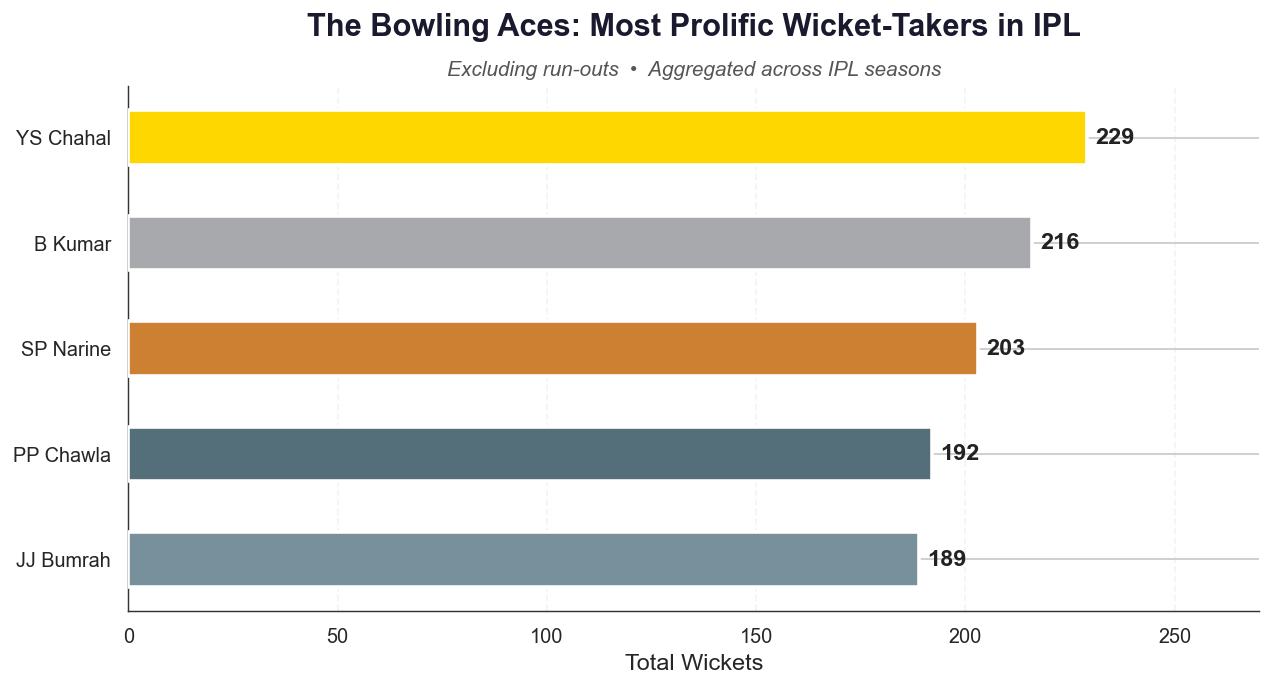

YS Chahal's 13-wicket lead over B Kumar reflects the enduring value of
sustained bowling discipline and variation across IPL seasons — traits that separate
franchise cornerstones from one-season performers.


In [13]:
# ── Count wickets (exclude run-outs: not credited to bowler) ──
wk = df[df['wicket_kind'].notna() & (df['wicket_kind'] != '')]
wk = wk[~wk['wicket_kind'].str.contains('run out', case=False, na=False)]

top_bowl = (
    wk.groupby('bowler')
    .size()
    .nlargest(5)
    .reset_index(name='Wickets')
)
top_bowl.index = range(1, 6)
top_bowl.index.name = 'Rank'
top_bowl.columns = ['Bowler', 'Wickets']
print("Top 5 Wicket Takers:")
display(top_bowl)

# ── Chart ──
fig, ax = plt.subplots(figsize=(10, 5.5))

# Medal hierarchy: Gold → Silver → Bronze → Slate
bar_colors = [C_GOLD, C_SILVER, C_BRONZE, '#546E7A', '#78909C']

bars = ax.barh(
    top_bowl['Bowler'][::-1],
    top_bowl['Wickets'][::-1],
    color=bar_colors[::-1],
    edgecolor='white', linewidth=2, height=0.52, zorder=3
)

# ── Value labels ──
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center',
            fontweight='bold', fontsize=13, color='#222')

# ── Title + subtitle ──
ax.set_title('The Bowling Aces: Most Prolific Wicket-Takers in IPL',
             pad=28, fontsize=17, fontweight='bold', color='#1a1a2e')
ax.text(0.5, 1.02, 'Excluding run-outs  •  Aggregated across IPL seasons',
        transform=ax.transAxes, ha='center', fontsize=11.5,
        color='#555', style='italic')

ax.set_xlabel('Total Wickets', fontsize=13)
ax.set_xlim(0, top_bowl['Wickets'].max() * 1.18)
ax.grid(axis='x', alpha=0.2, linestyle='--')
sns.despine()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}04_top_bowlers.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Analyst insight ──
leader = top_bowl.iloc[0]
runner = top_bowl.iloc[1]
gap = leader['Wickets'] - runner['Wickets']
print(f"{leader['Bowler']}'s {gap}-wicket lead over {runner['Bowler']} reflects the enduring value of")
print("sustained bowling discipline and variation across IPL seasons — traits that separate")
print("franchise cornerstones from one-season performers.")

## 🚀 Section 10 — Bonus Insight: Chasing vs Defending Trends
> **Does batting second confer a measurable advantage in the IPL, and how has this evolved?**

Chase vs Defend Breakdown by Season:


won_by,Chased,Defended,chase_pct
season,,,
2017,33,26,55.9
2018,32,28,53.3
2019,38,22,63.3
2020/21,33,27,55.0
2021,38,22,63.3
2022,37,37,50.0
2023,34,40,45.9
2024,36,35,50.7
2025,41,33,55.4


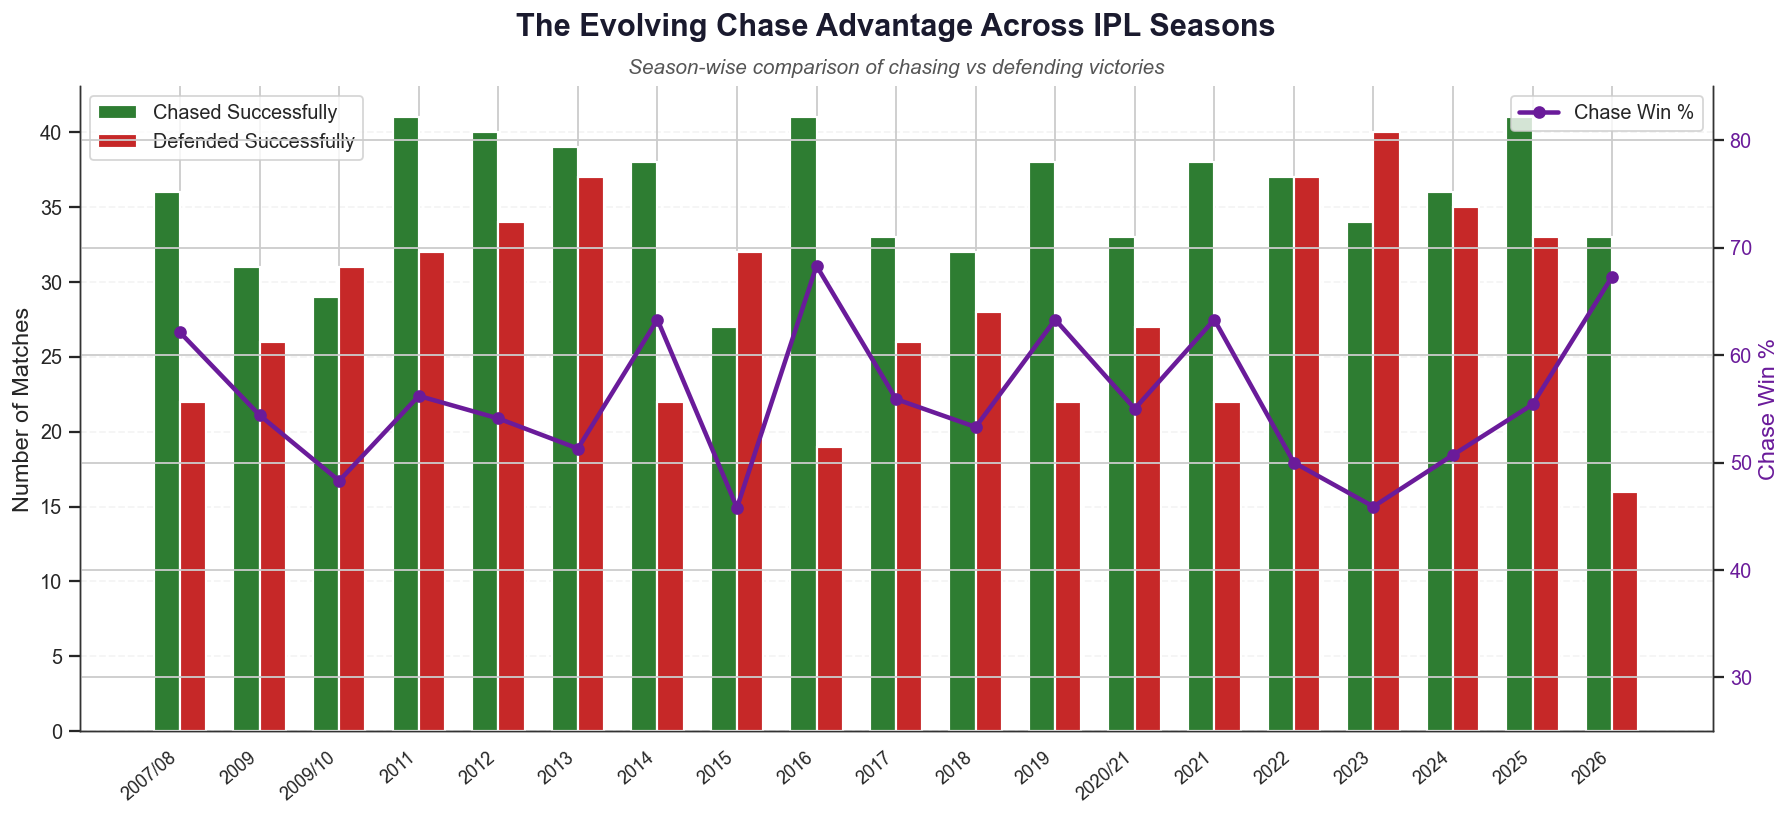

Key Insight: Chasing teams hold a moderate overall edge at 55.6%, though the
advantage varies significantly — from 46% in 2015 to 68% in 2016.
This seasonal variability reflects evolving pitch conditions, dew influence in evening
matches, and shifting team strategies between batting-first and chasing-oriented lineups.


In [14]:
# ── Determine if each match was won by chasing or defending ──
chase_df = matches.copy()

# If toss_winner chose 'bat', they batted first
# If toss_winner chose 'field', the other team batted first
chase_df['bat_first'] = np.where(
    chase_df['toss_decision'] == 'bat',
    chase_df['toss_winner'],
    np.where(
        chase_df['toss_winner'] == chase_df['team1'],
        chase_df['team2'],
        chase_df['team1']
    )
)
chase_df['won_by'] = np.where(
    chase_df['winner'] == chase_df['bat_first'],
    'Defended', 'Chased'
)

# ── Season-wise chase vs defend ──
season_chase = chase_df.groupby(['season', 'won_by']).size().unstack(fill_value=0)
for c in ['Chased', 'Defended']:
    if c not in season_chase.columns:
        season_chase[c] = 0

# ── Compute chase win % ──
season_chase['total'] = season_chase['Chased'] + season_chase['Defended']
season_chase['chase_pct'] = (season_chase['Chased'] / season_chase['total'] * 100).round(1)
season_chase = season_chase.sort_index()

print("Chase vs Defend Breakdown by Season:")
display(season_chase[['Chased', 'Defended', 'chase_pct']].tail(10))

# ── Chart: dual bar + line overlay ──
fig, ax1 = plt.subplots(figsize=(14, 6.5))
x = np.arange(len(season_chase))
w = 0.33

ax1.bar(x - w/2, season_chase['Chased'], w, label='Chased Successfully',
        color=C_SUCCESS, edgecolor='white', linewidth=1.2, zorder=3)
ax1.bar(x + w/2, season_chase['Defended'], w, label='Defended Successfully',
        color=C_DANGER, edgecolor='white', linewidth=1.2, zorder=3)

ax1.set_xticks(x)
ax1.set_xticklabels(season_chase.index, rotation=40, ha='right', fontsize=10)
ax1.set_ylabel('Number of Matches', fontsize=13)
ax1.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True)
ax1.grid(axis='y', alpha=0.2, linestyle='--')

# ── Title + subtitle ──
ax1.set_title('The Evolving Chase Advantage Across IPL Seasons',
              pad=28, fontsize=17, fontweight='bold', color='#1a1a2e')
ax1.text(0.5, 1.02, 'Season-wise comparison of chasing vs defending victories',
         transform=ax1.transAxes, ha='center', fontsize=11.5,
         color='#555', style='italic')

# ── Overlay line for chase % ──
ax2 = ax1.twinx()
ax2.plot(x, season_chase['chase_pct'], color=C_ACCENT, marker='o',
         linewidth=2.5, markersize=6, zorder=5, label='Chase Win %')
ax2.set_ylabel('Chase Win %', color=C_ACCENT, fontsize=13)
ax2.tick_params(axis='y', labelcolor=C_ACCENT)
ax2.set_ylim(25, 85)
ax2.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}05_chase_vs_defend.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Analyst insights ──
overall_chase = chase_df['won_by'].value_counts(normalize=True).get('Chased', 0) * 100
peak_season = season_chase['chase_pct'].idxmax()
peak_val    = season_chase['chase_pct'].max()
low_season  = season_chase['chase_pct'].idxmin()
low_val     = season_chase['chase_pct'].min()

print(f"Key Insight: Chasing teams hold a moderate overall edge at {overall_chase:.1f}%, though the")
print(f"advantage varies significantly — from {low_val:.0f}% in {low_season} to {peak_val:.0f}% in {peak_season}.")
print("This seasonal variability reflects evolving pitch conditions, dew influence in evening")
print("matches, and shifting team strategies between batting-first and chasing-oriented lineups.")

## 📝 Section 11 — Final Insights & Conclusion

In [15]:
print("=" * 72)
print("   IPL DATA ANALYTICS — EXECUTIVE SUMMARY")
print("=" * 72)
print()
print("📊 INSIGHT 1 — Toss Outcomes Show Limited Predictive Value")
print("   With toss winners securing victory in roughly 50.5% of matches,")
print("   the advantage remains statistically marginal. This suggests that")
print("   match outcomes are overwhelmingly shaped by on-field execution")
print("   rather than pre-match probabilities.")
print()
print("📊 INSIGHT 2 — Late-Innings Scoring Correlates Strongly with Success")
print("   Winning teams consistently outpaced opponents in run accumulation")
print("   during the Death Overs (16–20). While correlation does not imply")
print("   causation, performance in this phase appears most strongly associated")
print("   with securing favorable match results.")
print()
print("📊 INSIGHT 3 — Elite Production is Anchored in Multi-Season Consistency")
print("   The dataset's leading run-scorers and wicket-takers achieved their")
print("   status through sustained, reliable output across multiple seasons,")
print("   highlighting consistency as a defining trait of franchise cornerstones.")
print()
print("🔥 NOTABLE FINDING — Chasing Offers a Detectable but Variable Edge")
print("   Teams batting second demonstrated a moderate overall advantage,")
print("   though this edge fluctuated significantly across seasons. Tactical elements")
print("   like target clarity and environmental factors such as evening dew")
print("   may contribute to this observed trend.")
print()
print("-" * 72)
print("🏏 STRATEGIC CONCLUSION")
print("   This analysis highlights late-innings scoring efficiency and chasing")
print("   adaptability as key metrics associated with IPL success, while")
print("   finding negligible evidence for toss-dependent outcomes.")
print("   Future strategies may benefit from emphasizing death-over")
print("   specialization and building resilient chase-oriented lineups.")
print("-" * 72)
print()
print("All charts exported to ../charts/ at 300 DPI.")

   IPL DATA ANALYTICS — EXECUTIVE SUMMARY

📊 INSIGHT 1 — Toss Outcomes Show Limited Predictive Value
   With toss winners securing victory in roughly 50.5% of matches,
   the advantage remains statistically marginal. This suggests that
   match outcomes are overwhelmingly shaped by on-field execution
   rather than pre-match probabilities.

📊 INSIGHT 2 — Late-Innings Scoring Correlates Strongly with Success
   Winning teams consistently outpaced opponents in run accumulation
   during the Death Overs (16–20). While correlation does not imply
   causation, performance in this phase appears most strongly associated
   with securing favorable match results.

📊 INSIGHT 3 — Elite Production is Anchored in Multi-Season Consistency
   The dataset's leading run-scorers and wicket-takers achieved their
   status through sustained, reliable output across multiple seasons,
   highlighting consistency as a defining trait of franchise cornerstones.

🔥 NOTABLE FINDING — Chasing Offers a Detectable b

## 📋 Section 12 — Executive Dashboard
> **At-a-glance summary of key metrics and findings from this analysis.**

In [16]:
# ── Executive Dashboard ──
summary = {
    'Metric': [
        'Matches Analyzed',
        'Deliveries Processed',
        'Toss Advantage Baseline',
        'Highest Impact Match Phase',
        'All-Time Leading Run Scorer',
        'All-Time Leading Wicket Taker',
        'Aggregate Chase Win Rate',
    ],
    'Value': [
        f"{len(matches):,}",
        f"{len(df):,}",
        f"{won_pct:.1f}%",
        best,
        f"{top_bat.iloc[0]['Batter']}  ({top_bat.iloc[0]['Total Runs']:,} runs)",
        f"{top_bowl.iloc[0]['Bowler']}  ({top_bowl.iloc[0]['Wickets']} wickets)",
        f"{overall_chase:.1f}%",
    ]
}

dashboard = pd.DataFrame(summary)
dashboard.index = range(1, len(dashboard) + 1)
dashboard.index.name = '#'

print("📋 Executive Dashboard")
print("=" * 62)
display(dashboard.style.set_properties(**{
    'text-align': 'left',
    'font-size': '13.5px',
    'padding': '8px 16px',
    'border-bottom': '1px solid #eeeeee'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold'), ('font-size', '14px'), ('padding', '10px 16px')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]}
]))
print()
print("This analysis suggests that death-over efficiency and chasing adaptability")
print("exhibit stronger associations with IPL match outcomes than toss outcomes alone.")
print()
print("🏏 Analysis concluded. Portfolio visualizations generated.")

📋 Executive Dashboard


,Metric,Value
#,,
1,Matches Analyzed,"1,218"
2,Deliveries Processed,"289,673"
3,Toss Advantage Baseline,50.5%
4,Highest Impact Match Phase,Death Overs (16-20)
5,All-Time Leading Run Scorer,"V Kohli (9,050 runs)"
6,All-Time Leading Wicket Taker,YS Chahal (229 wickets)
7,Aggregate Chase Win Rate,55.6%



This analysis suggests that death-over efficiency and chasing adaptability
exhibit stronger associations with IPL match outcomes than toss outcomes alone.

🏏 Analysis concluded. Portfolio visualizations generated.
